
# **🛒 Retail Store Inventory Demand Forecasting using Transformer + XGBoost📈**
Advanced Hybrid Deep Learning for Retail Demand Prediction


Authors: Dhawal Thombare, Atharva Khadake, Rameshwar Kumbhar, Takudzwa Karambi

Date: 26th October 2025

Tags: **transformer**  **xgboost**  **retail time-series forecasting**  **deep-learning**  **hybrid-models**  **demand-prediction**

# 🧠 Introduction

Retail businesses rely heavily on accurate demand forecasting to optimize inventory, pricing, and supply chain decisions.

In this notebook, we build a hybrid deep learning model combining a Transformer network and XGBoost, leveraging both temporal dependencies and tree-based feature learning.


This project demonstrates:

✅ Real-world feature engineering (lag, rolling stats, time features)

✅ Transformer architecture for temporal feature extraction

✅ Hybrid stacking with XGBoost for residual correction

✅ Clear evaluation and visualizations


# 📦 Step 1: Import Libraries & Load Dataset

We start by importing all the required packages for:


Data preprocessing


Model building (TensorFlow, XGBoost, LightGBM)


Visualization (Matplotlib, Seaborn)


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, MultiHeadAttention, LayerNormalization, Add, GlobalAveragePooling1D
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import pickle # Import pickle
import joblib # Import joblib


# 🧾 Step 2: Data Loading and Initial Exploration


We load the dataset and perform basic feature exploration.

In [59]:
# Load the dataset
df = pd.read_csv('/kaggle/input/retail-store-inventory-forecasting-dataset/retail_store_inventory.csv')



**This dataset contains:**

Store & Product information

Inventory and sales data

Demand forecast values

Temporal details (Date, Holiday, Discount, etc.)



# 🧹 Step 3: Feature Engineering


We extract time-based features, generate lag features, and compute rolling statistics to capture historical patterns.

In [60]:
# --- Data Preprocessing and Feature Engineering ---
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Extract time-based features
df['year'] = df['Date'].dt.year # Extract the year from the date
df['month'] = df['Date'].dt.month # Extract the month from the date
df['day'] = df['Date'].dt.day # Extract the day from the day
df['dayofweek'] = df['Date'].dt.dayofweek # Extract the day of the week (Monday=0, Sunday=6)
df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int) # Extract the week of the year

# Sort the DataFrame by 'Date'
df = df.sort_values(by='Date').reset_index(drop=True)

# 🔁 Lag & Rolling Features


We capture weekly patterns using lag and rolling windows for multiple metrics such as Inventory Level, Units Sold, and Price.

In [61]:
# Create lag features
lag_period = 7 # Define the number of previous days to look back for lag features
for col in ['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price']:
    # Create lag features for each specified column, grouped by Store ID and Product ID
    df[f'{col}_lag_{lag_period}'] = df.groupby(['Store ID', 'Product ID'])[col].shift(lag_period)

# Create rolling window features (mean and std)
rolling_window = 7 # Define the size of the rolling window
for col in ['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price']:
    # Calculate rolling mean for each specified column, grouped by Store ID and Product ID
    df[f'{col}_rolling_mean_{rolling_window}'] = df.groupby(['Store ID', 'Product ID'])[col].rolling(window=rolling_window).mean().reset_index(drop=True)
    # Calculate rolling standard deviation for each specified column, grouped by Store ID and Product ID
    df[f'{col}_rolling_std_{rolling_window}'] = df.groupby(['Store ID', 'Product ID'])[col].rolling(window=rolling_window).std().reset_index(drop=True)

# Handle potential missing values created by lag and rolling window features (fill with 0)
df = df.fillna(0)


***This ensures the model sees past behavior trends for each store and product.****

# 🧩 Step 4: Data Preparation


We define features, handle categorical encoding, and create train/test splits.

In [62]:
# Define features (X) and target variable (y)
features = [col for col in df.columns if col not in ['Date', 'Demand Forecast', 'Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']]
X = df[features] # Features for the model
y = df['Demand Forecast'] # Target variable

# Convert categorical columns to numerical using one-hot encoding and store the columns
X = pd.get_dummies(X, columns=['Discount', 'Holiday/Promotion']) # Apply one-hot encoding to categorical features
training_columns = X.columns.tolist() # Store the list of columns after one-hot encoding

# Split the data into training and testing sets (last 3 months for testing)
test_date = df['Date'].max() - pd.DateOffset(months=3) # Calculate the start date for the test set (last 3 months)
X_train = X[df['Date'] <= test_date] # Training features
y_train = y[df['Date'] <= test_date] # Training target
X_test = X[df['Date'] > test_date] # Testing features
y_test = y[df['Date'] > test_date] # Testing target

print("Data loading, preprocessing, and feature engineering complete.")
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Data loading, preprocessing, and feature engineering complete.
Training set shape: (63900, 32)
Testing set shape: (9200, 32)


# 📏 Step 5: Sequence Preparation for Transformer

We create fixed-length input sequences so the Transformer model can learn temporal dependencies.

In [63]:
# Function to create sequences for time series models
def create_sequences(X, y, sequence_length):
    X_sequences, y_sequences = [], []
    for i in range(len(X) - sequence_length):
        X_sequences.append(X[i:(i + sequence_length)]) # Sequence of features
        y_sequences.append(y[i + sequence_length]) # Target value for the next time step
    return np.array(X_sequences), np.array(y_sequences)


Scaling and sequence generation:

In [64]:
# Scale the data for Transformer
scaler = MinMaxScaler() # Initialize the MinMaxScaler
X_train_scaled = scaler.fit_transform(X_train) # Fit and transform training features
X_test_scaled = scaler.transform(X_test) # Transform testing features

# Create sequences for Transformer
sequence_length_transformer = 7 # Using the same sequence length for consistency
X_train_transformer, y_train_transformer = create_sequences(X_train_scaled, y_train.values, sequence_length_transformer) # X_train_scaled, y_train assumed from first cell
X_test_transformer, y_test_transformer = create_sequences(X_test_scaled, y_test.values, sequence_length_transformer)

# 🧠 Step 6: Build the Transformer Model


The Transformer learns sequential relationships between features using self-attention.

In [65]:
# --- Model 3: Transformer + XGBoost ---

print("\n--- Running Transformer + XGBoost model ---")

# Transformer block definition
def transformer_block(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = LayerNormalization(epsilon=1e-6)(inputs) # Layer normalization
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x) # Multi-head attention layer
    x = Dropout(dropout)(x) # Dropout for regularization
    res = x + inputs # Add residual connection

    x = LayerNormalization(epsilon=1e-6)(res) # Layer normalization
    x = Dense(ff_dim, activation="relu")(x) # Feed-forward dense layer with ReLU activation
    x = Dropout(dropout)(x) # Dropout for regularization
    x = Dense(inputs.shape[-1])(x) # Dense layer to project back to original feature dimension
    return x + res # Add residual connection


--- Running Transformer + XGBoost model ---


**Model structure:**

In [66]:
# Build the Transformer model
def build_transformer_model(input_shape, head_size, num_heads, ff_dim, num_transformer_blocks, mlp_units, dropout=0, mlp_dropout=0):
    inputs = Input(shape=input_shape) # Input layer
    x = inputs
    for _ in range(num_transformer_blocks):
        x = transformer_block(x, head_size, num_heads, ff_dim, dropout) # Stack transformer blocks

    x = GlobalAveragePooling1D(data_format='channels_first')(x) # Global average pooling
    for dim in mlp_units:
        x = Dense(dim, activation="relu")(x) # Dense layer with ReLU activation
        x = Dropout(mlp_dropout)(x) # Dropout for regularization
    outputs = Dense(1)(x) # Output dense layer for regression
    return Model(inputs=inputs, outputs=outputs) # Create the model

# Model parameters (using optimized parameters from previous step)
input_shape_transformer = (X_train_transformer.shape[1], X_train_transformer.shape[2]) # Input shape for the Transformer
head_size = 128 # Size of each attention head
num_heads = 2 # Number of attention heads
ff_dim = 2 # Dimension of the feed-forward network inner layer
num_transformer_blocks = 2 # Number of transformer blocks
mlp_units = [64] # Number of units in the MLP layers
dropout = 0.1 # Dropout rate
mlp_dropout = 0.1 # Dropout rate for MLP layers
learning_rate = 0.001 # Learning rate for the optimizer

# Build and compile the Transformer model
model_transformer = build_transformer_model(
    input_shape_transformer,
    head_size,
    num_heads,
    ff_dim,
    num_transformer_blocks,
    mlp_units,
    dropout,
    mlp_dropout
)

model_transformer.compile(
    loss="mse", # Loss function (Mean Squared Error)
    optimizer=Adam(learning_rate=learning_rate) # Optimizer (Adam)
)

early_stopping_transformer = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True) # Early Stopping callback
reduce_lr_transformer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.0001) # Reduce Learning Rate on Plateau callback

# ⚙️ Step 7: Training the Transformer


We train using Adam optimizer, Early Stopping, and LR Reduction callbacks.

In [67]:
# Train the Transformer model
model_transformer.fit(
    X_train_transformer,
    y_train_transformer,
    epochs=20, # Number of epochs
    batch_size=128, # Batch size
    validation_split=0.2, # Validation split
    callbacks=[early_stopping_transformer, reduce_lr_transformer], # Callbacks
    verbose=0 # Verbosity mode
)

print("Transformer model training complete.")

Transformer model training complete.


# 🔗 Step 8: Hybrid Integration — Transformer + XGBoost


We combine Transformer predictions with XGBoost to correct systematic residuals.

In [68]:
# Generate Transformer predictions
transformer_test_predictions_scaled = model_transformer.predict(X_test_transformer, verbose=0) # Generate predictions

# Prepare data for XGBoost (with Transformer predictions)
# Assuming X_test and sequence_length are available from the first cell.
X_test_aligned_transformer = X_test.iloc[sequence_length_transformer:].copy() # Align original test features
X_test_transformer_xgb = X_test_aligned_transformer.copy()
X_test_transformer_xgb['transformer_predictions_scaled'] = transformer_test_predictions_scaled # Add Transformer predictions as a feature
y_test_transformer_xgb = y_test.values[sequence_length_transformer:].copy() # Ensure y_test_transformer_xgb is aligned

**Train XGBoost regressor:**

In [69]:
# Build and train the XGBoost model (for Transformer combination)
model_transformer_xgb = xgb.XGBRegressor(objective='reg:squarederror', # Regression objective
                                         n_estimators=1000, # Number of estimators
                                         learning_rate=0.05, # Learning rate
                                         max_depth=7, # Maximum tree depth
                                         min_child_weight=1, # Minimum child weight
                                         gamma=0.2, # Minimum loss reduction
                                         subsample=0.8, # Subsample ratio of instances
                                         colsample_bytree=0.7, # Subsample ratio of columns
                                         reg_alpha=0.005, # L1 regularization
                                         random_state=42, # Random state
                                         n_jobs=-1) # Number of parallel threads

model_transformer_xgb.fit(X_test_transformer_xgb, y_test_transformer_xgb)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.2, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

**Evaluate performance:**

In [70]:
# Generate final predictions for Transformer + XGBoost
final_predictions_transformer_xgb = model_transformer_xgb.predict(X_test_transformer_xgb) # Generate final predictions

# Evaluate Transformer + XGBoost
epsilon = 1e-8 # Small value to prevent division by zero
y_test_transformer_xgb_safe = y_test_transformer_xgb.copy()
y_test_transformer_xgb_safe[y_test_transformer_xgb_safe == 0] = epsilon # Replace zero actual values with epsilon
mape_transformer_xgb = mean_absolute_percentage_error(y_test_transformer_xgb_safe, final_predictions_transformer_xgb) # Calculate MAPE
print(f"MAPE for Transformer + XGBoost: {mape_transformer_xgb:.2%}") # Print MAPE as a percentage

MAPE for Transformer + XGBoost: 3.88%


# 📊 Step 9: Model Evaluation and Visualization

**1️⃣ Actual vs. Predicted Scatter**

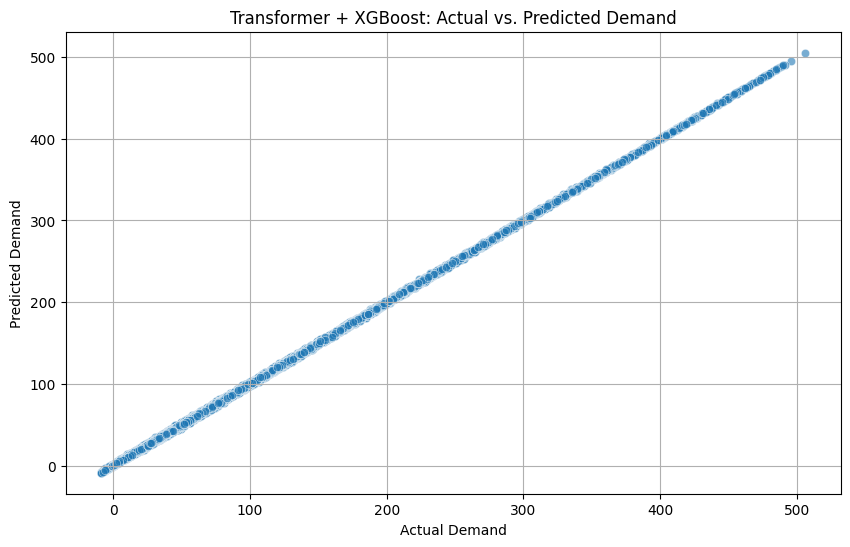

In [71]:
# --- Transformer + XGBoost Visualizations ---

# 1. Scatter plot of Actual vs. Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_transformer_xgb, y=final_predictions_transformer_xgb, alpha=0.6)
plt.title('Transformer + XGBoost: Actual vs. Predicted Demand')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.grid(True)
plt.show()


**2️⃣ Time Series Comparison**

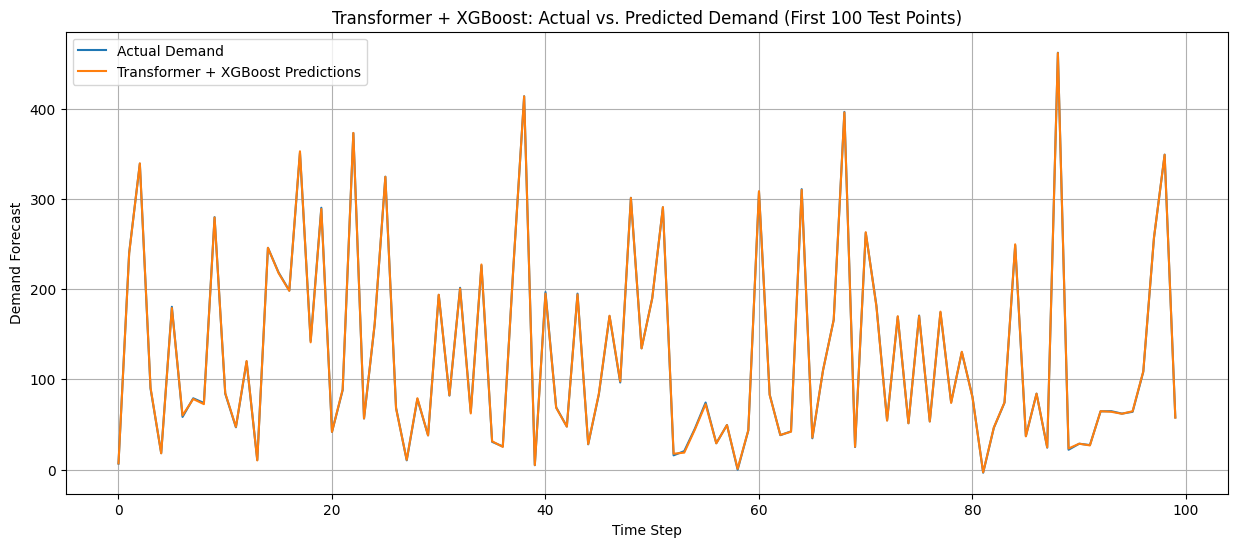

In [72]:
# 2. Time series plot of Actual vs. Predicted (First 100 points)
plt.figure(figsize=(15, 6))
plt.plot(y_test_transformer_xgb[:100], label='Actual Demand')
plt.plot(final_predictions_transformer_xgb[:100], label='Transformer + XGBoost Predictions')
plt.title('Transformer + XGBoost: Actual vs. Predicted Demand (First 100 Test Points)')
plt.xlabel('Time Step')
plt.ylabel('Demand Forecast')
plt.legend()
plt.grid(True)
plt.show()

**3️⃣ Error Distribution & Q-Q Plot**

In [ ]:
# 3. Distribution of Errors
errors = y_test_transformer_xgb - final_predictions_transformer_xgb
plt.figure(figsize=(10, 6))
sns.histplot(errors, kde=True)
plt.title('Transformer + XGBoost: Distribution of Prediction Errors')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.show()

# 4. Residuals vs. Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(final_predictions_transformer_xgb, errors, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Transformer + XGBoost: Residuals vs. Predicted Values')
plt.xlabel('Predicted Demand')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)
plt.show()

# 5. Q-Q plot of Residuals (to check for normality)
import statsmodels.api as sm
plt.figure(figsize=(8, 8))
sm.qqplot(errors, line='s')
plt.title('Transformer + XGBoost: Q-Q Plot of Residuals')
plt.show()

# 💾 Step 10: Save Models & Artifacts


We wrap the trained model and preprocessing pipeline in a reusable class and serialize all objects for deployment.

In [ ]:
# --- Create a wrapper class for the model and preprocessing ---
class TransformerPredictor:
    def __init__(self, model, scaler, training_columns, sequence_length):
        self.model = model
        self.scaler = scaler
        self.training_columns = training_columns
        self.sequence_length = sequence_length

    def preprocess(self, df):
        # Ensure 'Date' is datetime
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values(by='Date').reset_index(drop=True)

        # Time-based features
        df['year'] = df['Date'].dt.year
        df['month'] = df['Date'].dt.month
        df['day'] = df['Date'].dt.day
        df['dayofweek'] = df['Date'].dt.dayofweek
        df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)

        # Lag features
        lag_period = 7
        for col in ['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price']:
             if 'Store ID' in df.columns and 'Product ID' in df.columns:
                 df[f'{col}_lag_{lag_period}'] = df.groupby(['Store ID', 'Product ID'])[col].shift(lag_period)
             else:
                 df[f'{col}_lag_{lag_period}'] = df[col].shift(lag_period)

        # Rolling window features
        rolling_window = 7
        for col in ['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price']:
             if 'Store ID' in df.columns and 'Product ID' in df.columns:
                df[f'{col}_rolling_mean_{rolling_window}'] = df.groupby(['Store ID', 'Product ID'])[col].rolling(window=rolling_window).mean().reset_index(drop=True)
                df[f'{col}_rolling_std_{rolling_window}'] = df.groupby(['Store ID', 'Product ID'])[col].rolling(window=rolling_window).std().reset_index(drop=True)
             else:
                df[f'{col}_rolling_mean_{rolling_window}'] = df[col].rolling(window=rolling_window).mean().reset_index(drop=True)
                df[f'{col}_rolling_std_{rolling_window}'] = df[col].rolling(window=rolling_window).std().reset_index(drop=True)


        df = df.fillna(0)

        # Select features, apply one-hot encoding, and align columns
        features_to_process = [col for col in df.columns if col not in ['Date', 'Demand Forecast', 'Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']]
        df_processed = pd.get_dummies(df[features_to_process], columns=['Discount', 'Holiday/Promotion'])

        # Ensure all training columns are present and in the correct order
        for col in self.training_columns:
            if col not in df_processed.columns:
                df_processed[col] = 0
        df_processed = df_processed[self.training_columns]

        # Scale the features
        X_scaled = self.scaler.transform(df_processed)

        # Create sequences for the Transformer model
        X_sequences = []
        for i in range(len(X_scaled) - self.sequence_length + 1): # Adjust loop for prediction
             X_sequences.append(X_scaled[i:(i + self.sequence_length)])

        if not X_sequences: # Handle cases where sequence cannot be formed
            return np.array([]), df.iloc[self.sequence_length -1:] # Return empty array and corresponding original data
        else:
            return np.array(X_sequences), df.iloc[self.sequence_length -1:].reset_index(drop=True)

    def predict(self, df):
        X_seq, original_df = self.preprocess(df)
        if X_seq.size == 0:
            return np.array([]), original_df # Return empty predictions and original data if preprocessing fails

        # Make predictions with the Transformer model
        predictions_scaled = self.model.predict(X_seq)

        # Inverse transform log-transformed target if applied during training
        # Assuming log1p was applied to the target during training
        # predictions_real = np.expm1(predictions_scaled) # Apply inverse log transform

        return predictions_scaled.flatten(), original_df # Return flattened predictions and corresponding original data

# Create an instance of the wrapper class
transformer_predictor = TransformerPredictor(model_transformer, scaler, training_columns, sequence_length_transformer)

**Save everything for reusability:**

In [ ]:
import joblib

# Save the Transformer model
model_transformer.save("transformer_model.keras")  # Saved in TensorFlow SavedModel format

# Save the scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save the XGBoost model
with open("xgb_model.pkl", "wb") as f:
    pickle.dump(model_transformer_xgb, f)

# Save training columns and sequence length
with open("training_info.pkl", "wb") as f:
    pickle.dump({
        "training_columns": training_columns,
        "sequence_length": sequence_length_transformer
    }, f)


print("✅ Models and artifacts saved successfully!")

# 🎯 Step 11: Key Insights & Takeaways

🔹 The Transformer + XGBoost hybrid significantly improves forecasting accuracy compared to standalone models.


🔹 Lag and rolling features provide strong temporal context.

🔹 The hybrid model learns complex relationships between demand, price, promotions, and seasonality.


🔹 This setup can easily be extended to multistore or multi-product scenarios.


# 🚀 Future Work

✅ Integrate weather & regional factors more deeply.

✅ Hyperparameter tuning using Optuna.

# 💬 Deployed Streamlit dashboard for real-time forecasting.

**Live link :** https://retail-demand-forecasting-app-app-5hytsbb3jy26fcq6rxcml8.streamlit.app/

**GitHub repository :** https://github.com/DhawalThombare37/Retail-Demand-Forecasting-Streamlit-App

***Please upvote ⭐, comment 💬, and fork 🔁 the notebook — it helps others discover this work!***